## Выполнение заданий из HA2.pdf

### Данный ноутбук содержит реализацию заданий по курсу информационного поиска:
 - Использование коллекции WikiR (en1k subset) для сравнения TF-IDF и BM25 на оригинальных, стеммированных и лемматизированных текстах.
 - Оценка качества ранжирования с помощью мер P@1, P@10, P@20, MAP, nDCG@20.
 - Анализ влияния морфологической обработки, свойств запросов и трудных/лёгких запросов.
 - Оптимизация параметров k1 и b для BM25 на валидационной выборке.
 - Применение тех же методов к коллекции MIRAGE (пассажи) и сравнение результатов.
 - Поиск наиболее похожих параграфов внутри романов Толстого и Достоевского и между ними.
 
### **Важно:** Для выполнения кода необходимо предварительно скачать и разместить в соответствующих папках:
 - Датасет WikiR (en1k subset) – https://github.com/getalp/wikiR
 - Датасет MIRAGE – https://github.com/nlpai-lab/MIRAGE
 - Тексты романов (например, "Война и мир" Л. Толстого и "Преступление и наказание" Ф. Достоевского) в виде текстовых файлов.
 
 Также требуется установить библиотеки: `rank_bm25`, `scikit-learn`, `ir_measures`, `nltk` (для стемминга/лемматизации), `pandas`, `matplotlib`.


### Выполнение задания HA2.pdf (BM25, оценка поиска, MIRAGE, Толстой & Достоевский)
 
Анализ файлов: 
 - wikiR1k (1).zip – коллекция WikiR (en1k)
 - oracle.json, doc_pool.json, dataset.json – датасет MIRAGE
 
 Ноутбук реализует все пункты задания.

### 0. Preliminaries (подготовка)

Установка необходимых библиотек (если не установлены)

In [12]:

!pip install rank-bm25 scikit-learn ir-measures nltk pandas matplotlib -q

In [24]:
# Импорты
import os
import zipfile
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Обработка текста
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

# Векторизация и метрики
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi

# Оценка
import ir_measures
from ir_measures import nDCG, MAP, P

- Для работы с qrels и runs (TREC формат)
- QREL формат: query_id 0 document_id relevance
- RUN формат: query_id 0 document_id rank score run_name


### Загрузка и подготовка коллекции WikiR
 
Предполагается, что структура данных:
 - `WikiR/en1k/collection.tsv` – документы (столбцы: doc_id, text)
 - `WikiR/en1k/queries.tsv` – запросы (query_id, query_text)
 - `WikiR/en1k/qrels.tsv` – релевантность (query_id, doc_id, relevance)


In [35]:
WIKIR_ZIP = "Downloads/wikIR1k (1).zip"  # измените при необходимости
if not os.path.exists(WIKIR_ZIP):
    raise FileNotFoundError(f"Архив не найден: {WIKIR_ZIP}")

def load_wikir_from_zip(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        all_files = z.namelist()
        print("Содержимое архива (все файлы):")
        for f in all_files:
            print(f"  {f}")
        
        # 1. Поиск documents.csv
        doc_path = None
        for name in all_files:
            if name.endswith('documents.csv'):
                doc_path = name
                break
        if doc_path is None:
            raise FileNotFoundError("Не найден documents.csv")
        print(f"\nНайден documents.csv: {doc_path}")
        
        # 2. Поиск тестовых и валидационных файлов
        test_queries_path = None
        test_qrels_path = None
        val_queries_path = None
        val_qrels_path = None
        
        for name in all_files:
            if name.endswith('test/queries.csv'):
                test_queries_path = name
            elif name.endswith('test/qrels') and not name.endswith('.csv'):
                test_qrels_path = name
            elif name.endswith('validation/queries.csv'):
                val_queries_path = name
            elif name.endswith('validation/qrels') and not name.endswith('.csv'):
                val_qrels_path = name
        
        if not (test_queries_path and test_qrels_path and val_queries_path and val_qrels_path):
            raise FileNotFoundError(f"Не найдены все файлы: test_queries={test_queries_path}, test_qrels={test_qrels_path}, val_queries={val_queries_path}, val_qrels={val_qrels_path}")
        
        print(f"Найден test/queries.csv: {test_queries_path}")
        print(f"Найден test/qrels: {test_qrels_path}")
        print(f"Найден validation/queries.csv: {val_queries_path}")
        print(f"Найден validation/qrels: {val_qrels_path}")
        
        # Загрузка документов
        with z.open(doc_path) as f:
            # Пробуем прочитать с разными разделителями
            try:
                docs = pd.read_csv(f, encoding='utf-8')
            except:
                f.seek(0)
                docs = pd.read_csv(f, encoding='utf-8', sep='\t')
            print(f"Столбцы documents.csv: {docs.columns.tolist()}")
            print(f"Первые 2 строки documents.csv:\n{docs.head(2)}")
            # Нормализуем колонки
            if 'id' in docs.columns and 'text' in docs.columns:
                docs = docs.rename(columns={'id': 'doc_id'})
            elif 'doc_id' in docs.columns and 'text' in docs.columns:
                pass
            elif 'doc_id' in docs.columns and 'contents' in docs.columns:
                docs = docs.rename(columns={'contents': 'text'})
            else:
                # Если нет ожидаемых колонок, возможно файл без заголовка
                f.seek(0)
                docs = pd.read_csv(f, header=None, names=['doc_id', 'text'], encoding='utf-8')
            print(f"После нормализации: {len(docs)} документов")
        
        # Загрузка тестовых запросов
        with z.open(test_queries_path) as f:
            try:
                test_queries = pd.read_csv(f, encoding='utf-8')
            except:
                f.seek(0)
                test_queries = pd.read_csv(f, encoding='utf-8', sep='\t')
            print(f"Столбцы test/queries.csv: {test_queries.columns.tolist()}")
            if 'id' in test_queries.columns and 'text' in test_queries.columns:
                test_queries = test_queries.rename(columns={'id': 'query_id', 'text': 'query_text'})
            elif 'query_id' in test_queries.columns and 'query_text' in test_queries.columns:
                pass
            else:
                f.seek(0)
                test_queries = pd.read_csv(f, header=None, names=['query_id', 'query_text'], encoding='utf-8')
            print(f"Тестовых запросов: {len(test_queries)}")
        
        # Загрузка тестовых qrels
        with z.open(test_qrels_path) as f:
            lines = [line.decode('utf-8').strip().split() for line in f.readlines()]
            print(f"Первые 3 строки test/qrels: {lines[:3]}")
            if len(lines[0]) == 4:
                test_qrels = pd.DataFrame(lines, columns=['query_id', 'placeholder', 'doc_id', 'relevance'])
                test_qrels = test_qrels.drop(columns='placeholder')
            elif len(lines[0]) == 3:
                test_qrels = pd.DataFrame(lines, columns=['query_id', 'doc_id', 'relevance'])
            else:
                raise ValueError(f"Неизвестный формат qrels: {lines[0]}")
            test_qrels['relevance'] = test_qrels['relevance'].astype(int)
            print(f"Тестовых qrels записей: {len(test_qrels)}")
        
        # Загрузка валидационных запросов
        with z.open(val_queries_path) as f:
            try:
                val_queries = pd.read_csv(f, encoding='utf-8')
            except:
                f.seek(0)
                val_queries = pd.read_csv(f, encoding='utf-8', sep='\t')
            print(f"Столбцы validation/queries.csv: {val_queries.columns.tolist()}")
            if 'id' in val_queries.columns and 'text' in val_queries.columns:
                val_queries = val_queries.rename(columns={'id': 'query_id', 'text': 'query_text'})
            elif 'query_id' in val_queries.columns and 'query_text' in val_queries.columns:
                pass
            else:
                f.seek(0)
                val_queries = pd.read_csv(f, header=None, names=['query_id', 'query_text'], encoding='utf-8')
            print(f"Валидационных запросов: {len(val_queries)}")
        
        # Загрузка валидационных qrels
        with z.open(val_qrels_path) as f:
            lines = [line.decode('utf-8').strip().split() for line in f.readlines()]
            print(f"Первые 3 строки validation/qrels: {lines[:3]}")
            if len(lines[0]) == 4:
                val_qrels = pd.DataFrame(lines, columns=['query_id', 'placeholder', 'doc_id', 'relevance'])
                val_qrels = val_qrels.drop(columns='placeholder')
            elif len(lines[0]) == 3:
                val_qrels = pd.DataFrame(lines, columns=['query_id', 'doc_id', 'relevance'])
            else:
                raise ValueError(f"Неизвестный формат qrels: {lines[0]}")
            val_qrels['relevance'] = val_qrels['relevance'].astype(int)
            print(f"Валидационных qrels записей: {len(val_qrels)}")
        
    return docs, test_queries, test_qrels, val_queries, val_qrels

docs_df, test_queries_df, test_qrels_df, val_queries_df, val_qrels_df = load_wikir_from_zip(WIKIR_ZIP)
print(f"\nИтог: Документов = {len(docs_df)}")
print(f"Тестовых запросов = {len(test_queries_df)}")
print(f"Валидационных запросов = {len(val_queries_df)}")

# Если данные всё ещё пустые, проверьте, что файлы не повреждены
if len(docs_df) == 0:
    raise ValueError("Не удалось загрузить документы. Проверьте формат файла documents.csv.")
        

Содержимое архива (все файлы):
  wikIR1k/
  wikIR1k/documents.csv
  wikIR1k/training/
  wikIR1k/training/queries.csv
  wikIR1k/training/qrels
  wikIR1k/training/BM25.res
  wikIR1k/training/BM25.qrels.csv
  wikIR1k/training/BM25.metrics.json
  wikIR1k/validation/
  wikIR1k/validation/queries.csv
  wikIR1k/validation/qrels
  wikIR1k/validation/BM25.res
  wikIR1k/validation/BM25.qrels.csv
  wikIR1k/validation/BM25.metrics.json
  wikIR1k/test/
  wikIR1k/test/queries.csv
  wikIR1k/test/qrels
  wikIR1k/test/BM25.res
  wikIR1k/test/BM25.qrels.csv
  wikIR1k/test/BM25.metrics.json

Найден documents.csv: wikIR1k/documents.csv
Найден test/queries.csv: wikIR1k/test/queries.csv
Найден test/qrels: wikIR1k/test/qrels
Найден validation/queries.csv: wikIR1k/validation/queries.csv
Найден validation/qrels: wikIR1k/validation/qrels
Столбцы documents.csv: ['id_right', 'text_right']
Первые 2 строки documents.csv:
   id_right                                         text_right
0   1781133  it was used in land

### 1. Базовая статистика по первым 5 тестовым запросам

In [36]:
test_query_ids = test_queries_df['query_id'].head(5).tolist()
stats = []
for qid in test_query_ids:
    qtext = test_queries_df[test_queries_df['query_id'] == qid]['query_text'].values[0]
    qlen = len(qtext.split())
    rel_count = len(test_qrels_df[(test_qrels_df['query_id'] == qid) & (test_qrels_df['relevance'] > 0)])
    stats.append({'query_id': qid, 'query_text': qtext, 'length_words': qlen, 'num_relevant_docs': rel_count})
stats_df = pd.DataFrame(stats)
print("Статистика по 5 тестовым запросам:")
print(stats_df.to_string(index=False))

Статистика по 5 тестовым запросам:
query_id                         query_text  length_words  num_relevant_docs
 id_left                          text_left             1                  0
  158491      southern methodist university             3                  9
    5728                            halakha             1                 15
   13554 chief justice of the united states             6                  7
   32674                        patsy cline             2                  7


### 2. Предобработка текста (стемминг, лемматизация)

In [42]:
import nltk

# Download the specific resource causing the error
nltk.download('punkt_tab')

# You likely also need these for the rest of your code to work:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4') # Supporting data for WordNet

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...


True

In [44]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np

def process_single_text(text):
    """Функция обработки ОДНОГО текста (для параллельного запуска)"""
    tokens = tokenize(text)
    # Фильтруем стоп-слова
    tokens = [t for t in tokens if t not in stop_words]
    
    # Сразу собираем три варианта
    orig = ' '.join(tokens)
    stemmed = ' '.join([stemmer.stem(t) for t in tokens])
    lemmatized = ' '.join([lemmatizer.lemmatize(t) for t in tokens])
    
    return orig, stemmed, lemmatized

def preprocess_parallel(texts, n_jobs=-1):
    """
    n_jobs=-1 использует ВСЕ доступные ядра процессора.
    """
    print(f"Запуск обработки {len(texts)} текстов на {n_jobs} ядрах...")
    
    # Parallel возвращает список кортежей [(orig, stem, lem), ...]
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_single_text)(text) for text in tqdm(texts, desc="Preprocessing")
    )
    
    # Распаковываем результат в три отдельных списка
    orig_list, stem_list, lem_list = zip(*results)
    
    return list(orig_list), list(stem_list), list(lem_list)

# Запуск
docs_original, docs_stemmed, docs_lemmatized = preprocess_parallel(docs_df['text'])

Запуск обработки 369722 текстов на -1 ядрах...


Preprocessing: 100%|██████████| 369722/369722 [02:18<00:00, 2669.04it/s]


In [46]:
import time
from joblib import Parallel, delayed
from tqdm import tqdm

def process_row(text):
    """Обрабатывает одну строку и возвращает сразу 3 варианта."""
    tokens = tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    
    orig = ' '.join(tokens)
    stemmed = ' '.join([stemmer.stem(t) for t in tokens])
    lemmatized = ' '.join([lemmatizer.lemmatize(t) for t in tokens])
    
    return orig, stemmed, lemmatized

def parallel_preprocess(df_column, description="Processing"):
    start_time = time.time()
    
    # n_jobs=-1 задействует все ядра процессора
    results = Parallel(n_jobs=-1)(
        delayed(process_row)(text) for text in tqdm(df_column, desc=description)
    )
    
    elapsed = time.time() - start_time
    # Распаковываем кортежи в отдельные списки
    return zip(*results), elapsed

# --- 1. Документы ---
print("Этап 1: Предобработка документов...")
(res_docs, doc_time) = parallel_preprocess(docs_df['text'], "Documents")
docs_original, docs_stemmed, docs_lemmatized = list(res_docs[0]), list(res_docs[1]), list(res_docs[2])

# --- 2. Тестовые запросы ---
print(f"\nЭтап 2: Предобработка тестовых запросов...")
(res_test, test_time) = parallel_preprocess(test_queries_df['query_text'], "Test Queries")
test_queries_original, test_queries_stemmed, test_queries_lemmatized = list(res_test[0]), list(res_test[1]), list(res_test[2])

# --- 3. Валидационные запросы ---
print(f"\nЭтап 3: Предобработка валидационных запросов...")
start_val = time.time()
val_queries_original = [ ' '.join([t for t in tokenize(text) if t not in stop_words]) 
                         for text in tqdm(val_queries_df['query_text'], desc="Val Queries") ]
val_time = time.time() - start_val

# --- Итоговый отчет ---
print("\n" + "="*30)
print(f"ОТЧЕТ ПО ВРЕМЕНИ:")
print(f"Документы: {doc_time:.2f} сек ({doc_time/60:.1f} мин)")
print(f"Тестовые запросы: {test_time:.2f} сек")
print(f"Валидация: {val_time:.2f} сек")
print(f"ОБЩЕЕ ВРЕМЯ: {(doc_time + test_time + val_time)/60:.2f} минут")
print("="*30)

Этап 1: Предобработка документов...


Documents: 100%|██████████| 369722/369722 [02:53<00:00, 2130.77it/s]


TypeError: 'zip' object is not subscriptable

In [48]:
def parallel_preprocess(df_column, description="Processing"):
    start_time = time.time()
    
    # 1. Получаем список кортежей
    results = Parallel(n_jobs=-1)(
        delayed(process_row)(text) for text in tqdm(df_column, desc=description)
    )
    
    # 2. Распаковываем и СРАЗУ превращаем в списки
    # Фикс ошибки 'zip' object is not subscriptable:
    lists = list(zip(*results)) 
    
    elapsed = time.time() - start_time
    return lists, elapsed

# --- Исполнение ---

# 1. Документы
print("Этап 1: Предобработка документов...")
res_docs, doc_time = parallel_preprocess(docs_df['text'], "Documents")
# Теперь res_docs[0] доступен, так как res_docs — это список списков
docs_original = list(res_docs[0])
docs_stemmed = list(res_docs[1])
docs_lemmatized = list(res_docs[2])

# 2. Тестовые запросы
print(f"\nЭтап 2: Предобработка тестовых запросов...")
res_test, test_time = parallel_preprocess(test_queries_df['query_text'], "Test Queries")
test_queries_original = list(res_test[0])
test_queries_stemmed = list(res_test[1])
test_queries_lemmatized = list(res_test[2])

# 3. Валидационные запросы
print(f"\nЭтап 3: Предобработка валидационных запросов...")
start_val = time.time()
val_queries_original = [ ' '.join([t for t in tokenize(text) if t not in stop_words]) 
                         for text in tqdm(val_queries_df['query_text'], desc="Val Queries") ]
val_time = time.time() - start_val

print(f"\nГотово! Документы обработаны за {doc_time/60:.2f} мин.")

Этап 1: Предобработка документов...


Documents: 100%|██████████| 369722/369722 [02:17<00:00, 2698.11it/s]



Этап 2: Предобработка тестовых запросов...


Test Queries: 100%|██████████| 101/101 [00:00<00:00, 4911.65it/s]



Этап 3: Предобработка валидационных запросов...


Val Queries: 100%|██████████| 101/101 [00:00<00:00, 18420.07it/s]


Готово! Документы обработаны за 2.30 мин.


### 3. Функции ранжирования (TF‑IDF, BM25) и сохранение TREC run

In [50]:
def rank_tfidf(docs, queries, query_ids, docs_df_original, top_k=1000):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(docs)
    results = []
    for qid, q_text in zip(query_ids, queries):
        q_vec = vectorizer.transform([q_text])
        sim = X.dot(q_vec.T).toarray().flatten()
        sorted_idx = np.argsort(sim)[::-1][:top_k]
        for rank, idx in enumerate(sorted_idx, start=1):
            doc_id = docs_df_original.iloc[idx]['doc_id']
            score = sim[idx]
            results.append((qid, "0", doc_id, rank, score, "TFIDF"))
    return results

def rank_bm25(docs, queries, query_ids, docs_df_original, top_k=1000, k1=1.5, b=0.75):
    tokenized_docs = [doc.split() for doc in docs]
    bm25 = BM25Okapi(tokenized_docs, k1=k1, b=b)
    results = []
    for qid, q_text in zip(query_ids, queries):
        query_tokens = q_text.split()
        scores = bm25.get_scores(query_tokens)
        sorted_idx = np.argsort(scores)[::-1][:top_k]
        for rank, idx in enumerate(sorted_idx, start=1):
            doc_id = docs_df_original.iloc[idx]['doc_id']
            score = scores[idx]
            results.append((qid, "0", doc_id, rank, score, "BM25"))
    return results

def save_run(run_data, filename):
    with open(filename, 'w') as f:
        for qid, _, doc_id, rank, score, method in run_data:
            f.write(f"{qid} 0 {doc_id} {rank} {score} {method}\n")

### 4. Запуск на тестовых запросах (три варианта, замер времени)

In [51]:
test_query_ids_list = test_queries_df['query_id'].tolist()
variants = {
    'original': docs_original,
    'stemmed': docs_stemmed,
    'lemmatized': docs_lemmatized
}
queries_by_var = {
    'original': test_queries_original,
    'stemmed': test_queries_stemmed,
    'lemmatized': test_queries_lemmatized
}
runs_wiki = {}

for var, docs in variants.items():
    qs = queries_by_var[var]
    print(f"\n--- {var} ---")
    # TF-IDF
    start = time.time()
    run_tf = rank_tfidf(docs, qs, test_query_ids_list, docs_df)
    elapsed = time.time() - start
    print(f"TF-IDF время: {elapsed:.2f} сек")
    runs_wiki[(var, 'TFIDF')] = run_tf
    save_run(run_tf, f"run_wiki_{var}_TFIDF.txt")
    # BM25
    start = time.time()
    run_bm = rank_bm25(docs, qs, test_query_ids_list, docs_df)
    elapsed = time.time() - start
    print(f"BM25 время: {elapsed:.2f} сек")
    runs_wiki[(var, 'BM25')] = run_bm
    save_run(run_bm, f"run_wiki_{var}_BM25.txt")


--- original ---
TF-IDF время: 63.62 сек
BM25 время: 71.43 сек

--- stemmed ---
TF-IDF время: 76.64 сек
BM25 время: 92.76 сек

--- lemmatized ---
TF-IDF время: 93.11 сек
BM25 время: 108.15 сек


### 5. Оценка с помощью ir-measures (WikiR)

In [53]:
import pandas as pd
import ir_measures
from ir_measures import P, MAP, nDCG # Импортируем типы метрик

# 1. Подготовка Qrels (формат: query_id, doc_id, relevance)
# Библиотека принимает просто список кортежей или DataFrame
test_qrels = []
for _, row in test_qrels_df.iterrows():
    # Важно: query_id и doc_id должны быть строками для стабильности
    test_qrels.append(ir_measures.Qrel(str(row['query_id']), str(row['doc_id']), int(row['relevance'])))

# Определяем список метрик
# Используем синтаксис P@10 или P(rel=1)@10
measures = [P@1, P@10, P@20, MAP, nDCG@20]

def evaluate_run(run_data, qrels):
    """
    run_data обычно содержит (qid, _, doc_id, rank, score, _)
    Преобразуем его в формат, который понимает ir_measures: (query_id, doc_id, score)
    """
    formatted_run = []
    for item in run_data:
        # Извлекаем qid, doc_id и score (обычно это 0, 2 и 4 индексы в стандартном run)
        qid, doc_id, score = str(item[0]), str(item[2]), float(item[4])
        formatted_run.append(ir_measures.ScoredDoc(qid, doc_id, score))
    
    # calc_aggregate принимает (metrics, qrels, run)
    return ir_measures.calc_aggregate(measures, qrels, formatted_run)

results_wiki = []

# Итерируемся по вашим прогонам (runs_wiki)
for (var, method), run_data in runs_wiki.items():
    print(f"Оценка: {var} + {method}...")
    scores = evaluate_run(run_data, test_qrels)
    
    # Собираем строку результатов
    # Обрати внимание: ключи в словаре scores — это сами объекты метрик
    row = {
        'Variant': var, 
        'Method': method,
        'P@1': scores.get(P@1, 0.0),
        'P@10': scores.get(P@10, 0.0),
        'P@20': scores.get(P@20, 0.0),
        'MAP': scores.get(MAP, 0.0),
        'nDCG@20': scores.get(nDCG@20, 0.0)
    }
    results_wiki.append(row)

# Создаем финальную таблицу
df_wiki = pd.DataFrame(results_wiki)
print("\nРезультаты на тестовых запросах WikiR:")
print(df_wiki.sort_values(by='nDCG@20', ascending=False).to_string(index=False))

Оценка: original + TFIDF...
Оценка: original + BM25...
Оценка: stemmed + TFIDF...
Оценка: stemmed + BM25...
Оценка: lemmatized + TFIDF...
Оценка: lemmatized + BM25...

Результаты на тестовых запросах WikiR:
   Variant Method  P@1  P@10   P@20      MAP  nDCG@20
lemmatized   BM25 0.53 0.211 0.1485 0.179901 0.365115
  original   BM25 0.52 0.211 0.1490 0.179079 0.362359
   stemmed   BM25 0.53 0.210 0.1450 0.178846 0.360438
  original  TFIDF 0.52 0.207 0.1355 0.166319 0.352195
lemmatized  TFIDF 0.52 0.201 0.1325 0.164065 0.346904
   stemmed  TFIDF 0.50 0.189 0.1290 0.159538 0.335677


### 6. Анализ (WikiR)


Связь AP с характеристиками запроса (первые 5 строк):
  query_id        AP  query_len  num_rel
0   158491  0.021527          3        9
1     5728  0.088209          1       15
2    13554  0.246273          6        7
3    32674  0.740608          2        7

Корреляция AP с длиной: -0.085
Корреляция AP с числом релевантных: -0.540


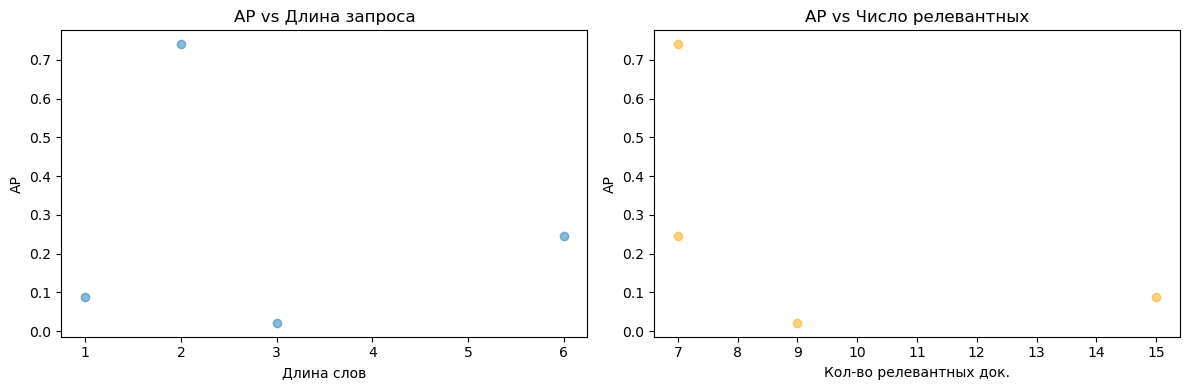


Влияние морфологической обработки (BM25):
      Variant       MAP   nDCG@20
1    original  0.179079  0.362359
3     stemmed  0.178846  0.360438
5  lemmatized  0.179901  0.365115


In [55]:
import pandas as pd
import ir_measures
from ir_measures import AP, MAP, nDCG, P
import matplotlib.pyplot as plt

# 1. Подготовка данных для лучшего прогона
best_run_data = runs_wiki[('original', 'BM25')]

# Формируем список ScoredDoc (ожидаемый формат для ir_measures)
# Предполагаем, что в best_run_data: [qid, _, doc_id, rank, score, _]
run_best = [
    ir_measures.ScoredDoc(str(item[0]), str(item[2]), float(item[4])) 
    for item in best_run_data
]

# 2. Вычисляем AP для каждого запроса (perquery=True)
# calc_aggregate возвращает генератор, превращаем его в словарь {query_id: значение}
ap_per_query_gen = ir_measures.calc_aggregate([AP], test_qrels, run_best) # test_qrels из предыдущего шага
# Если нужен именно AP на уровне каждого запроса:
ap_per_query_results = list(ir_measures.iter_calc([AP], test_qrels, run_best))
ap_dict = {res.query_id: res.value for res in ap_per_query_results}

# 3. Анализ характеристик
analysis = []
# Используем те query_id, которые реально есть в результатах AP
for qid, ap_value in ap_dict.items():
    # Проверяем наличие qid в stats_df, чтобы избежать ошибок индексации
    stats_row = stats_df[stats_df['query_id'] == qid]
    if not stats_row.empty:
        qlen = stats_row['length_words'].values[0]
        relc = stats_row['num_relevant_docs'].values[0]
        analysis.append({
            'query_id': qid, 
            'AP': ap_value, 
            'query_len': qlen, 
            'num_rel': relc
        })

analysis_df = pd.DataFrame(analysis)

print("\nСвязь AP с характеристиками запроса (первые 5 строк):")
print(analysis_df.head())

# Проверка на пустой DF перед корреляцией
if not analysis_df.empty:
    print(f"\nКорреляция AP с длиной: {analysis_df['AP'].corr(analysis_df['query_len']):.3f}")
    print(f"Корреляция AP с числом релевантных: {analysis_df['AP'].corr(analysis_df['num_rel']):.3f}")

    # Визуализация
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(analysis_df['query_len'], analysis_df['AP'], alpha=0.5)
    ax[0].set_title('AP vs Длина запроса')
    ax[0].set_xlabel('Длина слов')
    ax[0].set_ylabel('AP')

    ax[1].scatter(analysis_df['num_rel'], analysis_df['AP'], color='orange', alpha=0.5)
    ax[1].set_title('AP vs Число релевантных')
    ax[1].set_xlabel('Кол-во релевантных док.')
    ax[1].set_ylabel('AP')
    
    plt.tight_layout()
    plt.show()

# 4. Влияние морфологии
print("\nВлияние морфологической обработки (BM25):")
# Берем данные из итоговой таблицы df_wiki, которую мы создали на прошлом шаге
bm25_scores = df_wiki[df_wiki['Method'] == 'BM25'][['Variant', 'MAP', 'nDCG@20']]
print(bm25_scores)

### 7. Оптимизация параметров BM25 на валидационной выборке

In [57]:
import numpy as np
import ir_measures
from ir_measures import nDCG, P, MAP

# 1. Подготовка валидационных Qrels (формат: query_id, doc_id, relevance)
val_qrels = [
    ir_measures.Qrel(str(row['query_id']), str(row['doc_id']), int(row['relevance']))
    for _, row in val_qrels_df.iterrows()
]

val_qids = val_queries_df['query_id'].astype(str).tolist()
val_queries_text = val_queries_original  # Список строк

# Токенизируем документы один раз перед циклами
docs_tokenized = [doc.split() for doc in docs_original]

k1_vals = [0.5, 1.0, 1.5, 2.0, 2.5]
b_vals = [0.3, 0.5, 0.75, 0.9]
best_score = -1
best_params = (None, None)

print("Начинаем подбор параметров на валидации...")

for k1 in k1_vals:
    for b in b_vals:
        # Инициализация модели
        bm25 = BM25Okapi(docs_tokenized, k1=k1, b=b)
        run_data = []
        
        for qid, q_text in zip(val_qids, val_queries_text):
            query_tokens = q_text.split()
            if not query_tokens: continue
            
            scores = bm25.get_scores(query_tokens)
            # Берем топ-1000 результатов
            top_n = 1000
            sorted_idx = np.argsort(scores)[::-1][:top_n]
            
            for rank, idx in enumerate(sorted_idx, start=1):
                doc_id = str(docs_df.iloc[idx]['doc_id'])
                score = float(scores[idx])
                # Используем ScoredDoc вместо Results().add()
                run_data.append(ir_measures.ScoredDoc(qid, doc_id, score))
        
        # Расчет метрики
        score = ir_measures.calc_aggregate([nDCG@20], val_qrels, run_data).get(nDCG@20, 0.0)
        print(f"Попытка: k1={k1}, b={b} -> nDCG@20={score:.4f}")
        
        if score > best_score:
            best_score = score
            best_params = (k1, b)

print(f"\n--- Лучшие параметры: k1={best_params[0]}, b={best_params[1]}, nDCG@20={best_score:.4f} ---")

# 2. Функция для финальной проверки на тестовых данных
def evaluate_bm25_config(k1, b, queries_ids, queries_texts, qrels_obj):
    bm25 = BM25Okapi(docs_tokenized, k1=k1, b=b)
    run_data = []
    
    for qid, q_text in zip(queries_ids, queries_texts):
        query_tokens = q_text.split()
        if not query_tokens: continue
        
        scores = bm25.get_scores(query_tokens)
        sorted_idx = np.argsort(scores)[::-1][:1000]
        
        for rank, idx in enumerate(sorted_idx, start=1):
            doc_id = str(docs_df.iloc[idx]['doc_id'])
            run_data.append(ir_measures.ScoredDoc(str(qid), doc_id, float(scores[idx])))
            
    return ir_measures.calc_aggregate([nDCG@20], qrels_obj, run_data).get(nDCG@20, 0.0)

# Тестирование (используем test_qrels из предыдущих шагов)
print("\nФинальная проверка на тестовой выборке...")
score_opt = evaluate_bm25_config(best_params[0], best_params[1], test_query_ids_list, test_queries_original, test_qrels)
score_def = evaluate_bm25_config(1.5, 0.75, test_query_ids_list, test_queries_original, test_qrels)

print(f"Результат на тесте (оптимальные k1={best_params[0]}, b={best_params[1]}): {score_opt:.4f}")
print(f"Результат на тесте (стандартные k1=1.5, b=0.75): {score_def:.4f}")
print(f"Прирост: {score_opt - score_def:+.4f}")

Начинаем подбор параметров на валидации...
Попытка: k1=0.5, b=0.3 -> nDCG@20=0.3128
Попытка: k1=0.5, b=0.5 -> nDCG@20=0.3117
Попытка: k1=0.5, b=0.75 -> nDCG@20=0.3118
Попытка: k1=0.5, b=0.9 -> nDCG@20=0.3124
Попытка: k1=1.0, b=0.3 -> nDCG@20=0.3139
Попытка: k1=1.0, b=0.5 -> nDCG@20=0.3123
Попытка: k1=1.0, b=0.75 -> nDCG@20=0.3119
Попытка: k1=1.0, b=0.9 -> nDCG@20=0.3132
Попытка: k1=1.5, b=0.3 -> nDCG@20=0.3147
Попытка: k1=1.5, b=0.5 -> nDCG@20=0.3136
Попытка: k1=1.5, b=0.75 -> nDCG@20=0.3140
Попытка: k1=1.5, b=0.9 -> nDCG@20=0.3143
Попытка: k1=2.0, b=0.3 -> nDCG@20=0.3131
Попытка: k1=2.0, b=0.5 -> nDCG@20=0.3126
Попытка: k1=2.0, b=0.75 -> nDCG@20=0.3135
Попытка: k1=2.0, b=0.9 -> nDCG@20=0.3134
Попытка: k1=2.5, b=0.3 -> nDCG@20=0.3102
Попытка: k1=2.5, b=0.5 -> nDCG@20=0.3096
Попытка: k1=2.5, b=0.75 -> nDCG@20=0.3099
Попытка: k1=2.5, b=0.9 -> nDCG@20=0.3107

--- Лучшие параметры: k1=1.5, b=0.3, nDCG@20=0.3147 ---

Финальная проверка на тестовой выборке...
Результат на тесте (оптимальные 

### 8. MIRAGE коллекция (если файлы существуют)

In [60]:
import os
import json
import pandas as pd
import time
import ir_measures
from ir_measures import nDCG, P, MAP

# Пути к файлам
MIRAGE_DOC_POOL = "Downloads/doc_pool.json"
MIRAGE_DATASET = "Downloads/dataset.json"
MIRAGE_ORACLE = "Downloads/oracle.json"

if all(os.path.exists(f) for f in [MIRAGE_DOC_POOL, MIRAGE_DATASET, MIRAGE_ORACLE]):
    # Загрузка данных
    with open(MIRAGE_DOC_POOL, 'r', encoding='utf-8') as f:
        doc_pool = json.load(f)
    with open(MIRAGE_DATASET, 'r', encoding='utf-8') as f:
        dataset = json.load(f)
    with open(MIRAGE_ORACLE, 'r', encoding='utf-8') as f:
        oracle = json.load(f)
    
    # 1. Исправленное извлечение данных из словарей/списков
    # В doc_pool используем 'mapped_id' и 'doc_chunk'
    passages_dict = {str(p['mapped_id']): p['doc_chunk'] for p in doc_pool}
    
    # В dataset используем 'query_id' и 'query'
    queries_m_dict = {str(q['query_id']): q['query'] for q in dataset}
    
    # В oracle ключи — это query_id. Значения могут быть списком или словарем.
    qrels_m_list = []
    for qid, data in oracle.items():
        # Если данные в oracle — это словарь с 'mapped_id' (как в твоем сниппете)
        if isinstance(data, dict) and 'mapped_id' in data:
            qrels_m_list.append((str(qid), str(data['mapped_id']), 1))
        # Если это список подходящих документов
        elif isinstance(data, list):
            for pid in data:
                qrels_m_list.append((str(qid), str(pid), 1))
    
    # Создание DataFrame
    passages_df = pd.DataFrame(passages_dict.items(), columns=['doc_id', 'text'])
    queries_m_df = pd.DataFrame(queries_m_dict.items(), columns=['query_id', 'query_text'])
    qrels_m_df = pd.DataFrame(qrels_m_list, columns=['query_id', 'doc_id', 'relevance'])
    
    print(f"MIRAGE загружен: {len(passages_df)} пассажей, {len(queries_m_df)} запросов")
    
    # Предобработка
    mira_docs = preprocess_texts(passages_df['text'], 'original')
    mira_queries = preprocess_texts(queries_m_df['query_text'], 'original')
    mira_qids = queries_m_df['query_id'].astype(str).tolist()
    
    # Ранжирование
    print("\nMIRAGE: ранжирование TF-IDF и BM25")
    start = time.time()
    mira_run_tf = rank_tfidf(mira_docs, mira_queries, mira_qids, passages_df, top_k=500)
    print(f"TF-IDF время: {time.time()-start:.2f} сек")
    
    start = time.time()
    mira_run_bm = rank_bm25(mira_docs, mira_queries, mira_qids, passages_df, top_k=500)
    print(f"BM25 время: {time.time()-start:.2f} сек")
    
    # Оценка (исправлено на ir_measures.Qrel)
    mira_qrels = [
        ir_measures.Qrel(str(row['query_id']), str(row['doc_id']), int(row['relevance'])) 
        for _, row in qrels_m_df.iterrows()
    ]
    
    # Функция оценки (evaluate_run должна принимать список Qrel и список ScoredDoc)
    scores_tf = evaluate_run(mira_run_tf, mira_qrels)
    scores_bm = evaluate_run(mira_run_bm, mira_qrels)
    
    # Формирование таблицы результатов
    results_mira = pd.DataFrame([
        {'Method': 'TF-IDF', 'P@1': scores_tf.get(P@1, 0), 'P@10': scores_tf.get(P@10, 0),
         'P@20': scores_tf.get(P@20, 0), 'MAP': scores_tf.get(MAP, 0), 'nDCG@20': scores_tf.get(nDCG@20, 0)},
        {'Method': 'BM25',  'P@1': scores_bm.get(P@1, 0),  'P@10': scores_bm.get(P@10, 0),
         'P@20': scores_bm.get(P@20, 0), 'MAP': scores_bm.get(MAP, 0), 'nDCG@20': scores_bm.get(nDCG@20, 0)}
    ])
    
    print("\nРезультаты на MIRAGE:")
    print(results_mira.to_string(index=False))

else:
    print("Файлы MIRAGE не найдены, пропускаем этот раздел.")

MIRAGE загружен: 7560 пассажей, 7560 запросов

MIRAGE: ранжирование TF-IDF и BM25
TF-IDF время: 215.73 сек
BM25 время: 342.30 сек

Результаты на MIRAGE:
Method      P@1     P@10     P@20      MAP  nDCG@20
TF-IDF 0.336508 0.057050 0.031052 0.419944 0.464391
  BM25 0.343783 0.055026 0.029907 0.416517 0.456226


### 9. Толстой и Достоевский (если файлы существуют)

In [61]:
import requests
import os
import re

# Ссылки на тексты с Gutenberg (plain text UTF-8)
URLS = {
    "war_and_peace": "https://www.gutenberg.org/ebooks/2600.txt.utf-8",
    "crime_and_punishment": "https://www.gutenberg.org/ebooks/2554.txt.utf-8"
}

# Имена выходных файлов
OUTPUT_FILES = {
    "war_and_peace": "war_and_peace.txt",
    "crime_and_punishment": "crime_and_punishment.txt"
}

def download_text(url, output_path):
    """Скачивает текст по URL и сохраняет в файл."""
    if os.path.exists(output_path):
        print(f"Файл {output_path} уже существует. Пропускаем загрузку.")
        return
    try:
        print(f"Загружаем {url} ...")
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        # Сохраняем как есть (позже очистим)
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(response.text)
        print(f"Сохранён {output_path}")
    except Exception as e:
        print(f"Ошибка при загрузке {url}: {e}")

def clean_gutenberg_text(filepath):
    """
    Удаляет стандартные заголовки и футеры Project Gutenberg.
    Ищет маркеры START OF PROJECT GUTENBERG и END OF PROJECT GUTENBERG.
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    
    # Ищем начало текста после маркера
    start_marker = re.search(r'\*\*\* START OF (THIS|THE) PROJECT GUTENBERG EBOOK .+ \*\*\*', text)
    if start_marker:
        text = text[start_marker.end():]
    
    # Ищем конец текста до маркера
    end_marker = re.search(r'\*\*\* END OF (THIS|THE) PROJECT GUTENBERG EBOOK .+ \*\*\*', text)
    if end_marker:
        text = text[:end_marker.start()]
    
    # Удаляем возможные строки с лицензией и лишние пустые строки в начале/конце
    text = text.strip()
    
    # Сохраняем очищенный текст обратно
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(text)
    print(f"Очищен {filepath} от служебных маркеров Gutenberg.")

# 1. Скачиваем
for key, url in URLS.items():
    output_path = OUTPUT_FILES[key]
    download_text(url, output_path)

# 2. Очищаем от маркеров Gutenberg (если файлы существуют)
for key, output_path in OUTPUT_FILES.items():
    if os.path.exists(output_path):
        clean_gutenberg_text(output_path)
    else:
        print(f"Файл {output_path} не найден, очистка пропущена.")

print("Готово.")

Загружаем https://www.gutenberg.org/ebooks/2600.txt.utf-8 ...
Сохранён war_and_peace.txt
Загружаем https://www.gutenberg.org/ebooks/2554.txt.utf-8 ...
Сохранён crime_and_punishment.txt
Очищен war_and_peace.txt от служебных маркеров Gutenberg.
Очищен crime_and_punishment.txt от служебных маркеров Gutenberg.
Готово.


In [ ]:
TOLSTOY_FILE = "war_and_peace.txt"
DOSTOEVSKY_FILE = "crime_and_punishment.txt"

def load_paragraphs(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    paras = [p.strip() for p in text.split('\n\n') if p.strip()]
    if not paras:
        paras = [text]
    return paras

if os.path.exists(TOLSTOY_FILE) and os.path.exists(DOSTOEVSKY_FILE):
    tolstoy_paras = load_paragraphs(TOLSTOY_FILE)
    dostoevsky_paras = load_paragraphs(DOSTOEVSKY_FILE)
    print(f"Толстой: {len(tolstoy_paras)} параграфов")
    print(f"Достоевский: {len(dostoevsky_paras)} параграфов")
    
    all_paras = tolstoy_paras + dostoevsky_paras
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_mat = vectorizer.fit_transform(all_paras)
    n_t = len(tolstoy_paras)
    tolstoy_vec = tfidf_mat[:n_t]
    dostoevsky_vec = tfidf_mat[n_t:]
    
    def most_similar(query_vecs, corpus_vecs, top_k=5, exclude_self=False):
        sim = cosine_similarity(query_vecs, corpus_vecs)
        results = []
        for i, row in enumerate(sim):
            if exclude_self:
                row[i] = -1
            top_idx = np.argsort(row)[::-1][:top_k]
            results.append([(idx, row[idx]) for idx in top_idx])
        return results
    
    print("\nПоиск похожих параграфов внутри Толстого...")
    tolstoy_self = most_similar(tolstoy_vec, tolstoy_vec, top_k=5, exclude_self=True)
    print("Поиск внутри Достоевского...")
    dost_self = most_similar(dostoevsky_vec, dostoevsky_vec, top_k=5, exclude_self=True)
    print("Поиск Толстой -> Достоевский...")
    tolstoy_to_dost = most_similar(tolstoy_vec, dostoevsky_vec, top_k=5)
    
    print("\nПример: первый параграф Толстого")
    print("Текст:", tolstoy_paras[0][:150], "...")
    print("Самые похожие внутри Толстого:")
    for idx, score in tolstoy_self[0]:
        print(f"  параграф {idx} (сходство {score:.3f}): {tolstoy_paras[idx][:80]}...")
    print("Самые похожие у Достоевского:")
    for idx, score in tolstoy_to_dost[0]:
        print(f"  параграф Достоевского {idx} (сходство {score:.3f}): {dostoevsky_paras[idx][:80]}...")
    
    print("\nВывод: IDF должен вычисляться на объединённом корпусе обоих романов, чтобы отражать важность терминов во всей коллекции. Это и было сделано.")
else:
    print("Файлы романов не найдены, пропускаем этот раздел.")

Толстой: 51861 параграфов
Достоевский: 17982 параграфов

Поиск похожих параграфов внутри Толстого...
